# Section 9: Non Linear Regression Results
This notebook documents whether the colocalized variants in target gene show any signals in our interaction association analysis and quantile analysis. 

The steps are:
1. Load our interaction association or quantile analysis results.
2. Load the colocalized variants from Section 2.
3. Check their q-values in the corresponding files.

To apply this to other genes, simply `Ctrl+F` to replace `BIN1` with the gene of interest, or change the gene name in the block below.

## Load data

In [1]:
gene_name = 'BIN1'

In [2]:
library(data.table)
library(tidyverse)
source('/data/interactive_analysis/aw3600/xqtl-paper/codes/utilis.R')
tar_gene_info <- get_gene_info(gene_name = gene_name)
gene_id <- tar_gene_info$gene_info$region_id
chrom <- tar_gene_info$gene_info$`#chr`
dir.create(paste0('plots/', gene_name))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  masks data.table::minute()
✖ lubridate::month()   masks data.table::month()
✖ lubridate::quarter() masks data.table::quarter()
✖ lubridate::second()  masks data.table::second()
✖ purrr::transpose()   masks data.table::transpose()
✖ lubridate::wday()    masks data.table::wday()
✖ lubridate::week()    masks data.table::week()
✖ lubridate::yday()    masks data.table::yday()
✖ lubridate::year()    masks data.table::year()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to beco


Attaching package: ‘cowplot’




The following object is masked from ‘package:lubridate’:

    stamp




Warning message in dir.create(paste0("plots/", gene_name)):
“'plots/BIN1' already exists”


**FIXME: This suppose to read the coloc_res for our gene of interest, which generated by section 2, if instead the full cb_AD_res is used then we need to move it somewhere public**

In [3]:
# get variants in coloc set with AD
coloc_res <- readRDS("/data/interactive_analysis/aw3600//Figure_2b/cb_AD_res_study_May22.rds")
coloc_res_extracted <- coloc_res %>% filter(gene_ID == gene_id)
coloc_vars <- coloc_res_extracted %>% filter(study == "AD_Bellenguez") %>% pull(variant_ID)

# var_df <- readRDS(paste0(gene_name, "_colocboost_res.rds"))
# coloc_vars <- var_df %>% filter(str_detect(`colocalized phenotypes`, 'AD')) %>% pull(`colocalized variants`) %>% str_split(., ";", simplify = T) %>% as.character

In [4]:
coloc_res <- readRDS("/data/interactive_analysis/aw3600//Figure_2b/cb_AD_res_study_May22.rds")


In [5]:
head(coloc_res)

#chr,start,end,a1,a2,variant_ID,gene_ID,event_ID,cos_ID,vcp,cos_npc,min_npc_outcome,coef,study,contexts
<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,23954614,23954616,T,C,chr1:23954616:C:T,ENSG00000188529,AC_lf2_sQTL_chr1:23972012:23974468:clu_7647_-:UP:ENSG00000188529; AC_lf2_sQTL_chr1:23972012:23980190:clu_7647_-:UP:ENSG00000188529; DLPFC_lf2_sQTL_chr1:23972012:23974468:clu_8632_-:UP:ENSG00000188529; DLPFC_lf2_sQTL_chr1:23972012:23980190:clu_8632_-:UP:ENSG00000188529; DeJager_Exc_ENSG00000188529; DeJager_OPC_ENSG00000188529; Kellis_Ast_ENSG00000188529; Kellis_Exc_ENSG00000188529; Kellis_Inh_ENSG00000188529; Kellis_OPC_ENSG00000188529; Kellis_Oli_ENSG00000188529; PCC_lf2_sQTL_chr1:23972012:23974468:clu_7132_-:UP:ENSG00000188529; PCC_lf2_sQTL_chr1:23972012:23974973:clu_7132_-:PR:ENSG00000188529; ROSMAP_DLPFC_ENSG00000188529; AD_Bellenguez,ENSG00000188529:cos1:y6_y7_y12_y14_y16_y19_y21_y22_y23_y25_y26_y30_y31_y33_y36,0.01942333,1,0.3806,0.0180121657741215;9.611660795515e-05;2.02441164913636e-05;0.00422907574755353;0.0132502212456439;0.0527781256592643;0.0125245669515004;0.00615527080336954;0.00341898027930769;0.00198653997257985;0.0110332817065151;0.00207373895539244;-0.00301849686594544;0.00126579491493955;0.0002135859619029,AD_Bellenguez,"Ast_Kellis_eQTL, DLPFC_DeJager_eQTL, Exc_DeJager_eQTL, Exc_Kellis_eQTL, Inh_Kellis_eQTL, OPC_DeJager_eQTL, OPC_Kellis_eQTL, Oli_Kellis_eQTL, ROSMAP_AC_sQTL, ROSMAP_DLPFC_sQTL, ROSMAP_PCC_sQTL"
1,23958214,23958216,G,A,chr1:23958216:A:G,ENSG00000188529,AC_lf2_sQTL_chr1:23972012:23974468:clu_7647_-:UP:ENSG00000188529; AC_lf2_sQTL_chr1:23972012:23980190:clu_7647_-:UP:ENSG00000188529; DLPFC_lf2_sQTL_chr1:23972012:23974468:clu_8632_-:UP:ENSG00000188529; DLPFC_lf2_sQTL_chr1:23972012:23980190:clu_8632_-:UP:ENSG00000188529; DeJager_Exc_ENSG00000188529; DeJager_OPC_ENSG00000188529; Kellis_Ast_ENSG00000188529; Kellis_Exc_ENSG00000188529; Kellis_Inh_ENSG00000188529; Kellis_OPC_ENSG00000188529; Kellis_Oli_ENSG00000188529; PCC_lf2_sQTL_chr1:23972012:23974468:clu_7132_-:UP:ENSG00000188529; PCC_lf2_sQTL_chr1:23972012:23974973:clu_7132_-:PR:ENSG00000188529; ROSMAP_DLPFC_ENSG00000188529; AD_Bellenguez,ENSG00000188529:cos1:y6_y7_y12_y14_y16_y19_y21_y22_y23_y25_y26_y30_y31_y33_y36,0.05197918,1,0.3806,0.00364873723492476;0.00965818503719057;0.00789091550595531;0.0027718443410797;0.00237910819078775;0.000200071593697922;0.00032037969658088;0.0103484469093435;0.00322319795542317;0.0074982603826919;0.000319958970132186;0.0021256715391618;-0.00782220505504492;0.00589368180168127;5.57504639217958e-05,AD_Bellenguez,"Ast_Kellis_eQTL, DLPFC_DeJager_eQTL, Exc_DeJager_eQTL, Exc_Kellis_eQTL, Inh_Kellis_eQTL, OPC_DeJager_eQTL, OPC_Kellis_eQTL, Oli_Kellis_eQTL, ROSMAP_AC_sQTL, ROSMAP_DLPFC_sQTL, ROSMAP_PCC_sQTL"
1,23961288,23961290,G,GCTT,chr1:23961290:GCTT:G,ENSG00000188529,AC_lf2_sQTL_chr1:23972012:23974468:clu_7647_-:UP:ENSG00000188529; AC_lf2_sQTL_chr1:23972012:23980190:clu_7647_-:UP:ENSG00000188529; DLPFC_lf2_sQTL_chr1:23972012:23974468:clu_8632_-:UP:ENSG00000188529; DLPFC_lf2_sQTL_chr1:23972012:23980190:clu_8632_-:UP:ENSG00000188529; DeJager_Exc_ENSG00000188529; DeJager_OPC_ENSG00000188529; Kellis_Ast_ENSG00000188529; Kellis_Exc_ENSG00000188529; Kellis_Inh_ENSG00000188529; Kellis_OPC_ENSG00000188529; Kellis_Oli_ENSG00000188529; PCC_lf2_sQTL_chr1:23972012:23974468:clu_7132_-:UP:ENSG00000188529; PCC_lf2_sQTL_chr1:23972012:23974973:clu_7132_-:PR:ENSG00000188529; ROSMAP_DLPFC_ENSG00000188529; AD_Bellenguez,ENSG00000188529:cos1:y6_y7_y12_y14_y16_y19_y21_y22_y23_y25_y26_y30_y31_y33_y36,0.18081217,1,0.3806,0.00773683560523655;0.00563889262684326;0.00743983490082531;0.00288045251571567;0.0195919755911937;0.000454962240404439;0.00335471552638581;0.0300469293254764;0.00427932154069512;0.00966061526526633;0.000906694546048348;0.00538620611372211;-0.0139502868835968;0.0121667999602553;2.22556034506681e-05,AD_Bellenguez,"Ast_Kellis_eQTL, DLPFC_DeJager_eQTL, Exc_DeJager_eQTL, Exc_Kellis

## Interaction QTL

### Interaction with APOE

* check whether the folder related with APOE changed

In [6]:
#dlpfc_int_res <- fread(paste0('/data/analysis_result/cis_association/ROSMAP/eQTL/DLPFC/interaction/APOE/dlpfc_batch_all.rnaseqc.low_expression_filtered.outlier_removed.tmm.expression.bed.',chrom,'.mol_phe_',chrom,'_APOE.cis_qtl.pairs.tsv.gz')) %>% mutate(region  = "DLPFC")

In [7]:
#head(dlpfc_int_res)


#integrate all the cis association results
folders <- c("AC", "DLPFC", "PCC", "monocyte", "snuc_DeJager", "snuc_Kellis", "snuc_mega")
for(folder in folders) {
  int_res <- data.frame()
  if(folder == "AC"){
      tmp <- fread(paste0("/data/analysis_result/cis_association/ROSMAP/eQTL/", folder, "/interaction/APOE/AC_samples_list.rnaseqc.gene_tpm.low_expression_filtered.outlier_removed.tmm.expression.bed.",chrom, "_", chrom, "_APOE.cis_qtl.pairs.tsv.gz"))%>% mutate(region = "AC")
  }
  if(folder == "DLPFC"){
      tmp <- fread(paste0("/data/analysis_result/cis_association/ROSMAP/eQTL/", folder, "/interaction/APOE/dlpfc_batch_all.rnaseqc.low_expression_filtered.outlier_removed.tmm.expression.bed.", chrom, ".mol_phe_", chrom, "_APOE.cis_qtl.pairs.tsv.gz"))%>%mutate(region = "DLPFC")
  }
  if(folder == "PCC"){
      tmp <- fread(paste0("/data/analysis_result/cis_association/ROSMAP/eQTL/", folder, "/interaction/APOE/PCC_samples_list.rnaseqc.gene_tpm.low_expression_filtered.outlier_removed.tmm.expression.bed.", chrom, "_", chrom, "_APOE.cis_qtl.pairs.tsv.gz"))%>%mutate(region = "PCC")
  }
  if(folder == "snuc_DeJager"){
     tmp <- data.frame()
     contexts <- list.files(paste0("/data/analysis_result/cis_association/ROSMAP/eQTL/", folder))
     for(context in contexts){
         sub_tmp <- fread(paste0("/data/analysis_result/cis_association/ROSMAP/eQTL/",folder,"/", context,"/interaction/APOE/",context,".log2cpm.bed.",chrom,"_",chrom,"_APOE.cis_qtl.pairs.tsv.gz")) %>% mutate(region = paste0("DeJager_",context))
         tmp <- rbind(tmp, sub_tmp)
     }
  }
  if(folder == "snuc_Kellis"){
     tmp <- data.frame()
     contexts <- list.files(paste0("/data/analysis_result/cis_association/ROSMAP/eQTL/", folder))
     for(context in contexts){
         sub_tmp <- fread(paste0("/data/analysis_result/cis_association/ROSMAP/eQTL/",folder,"/", context,"/interaction/APOE/snuc_pseudo_bulk.", context, ".normalized.log2cpm.bed.",chrom, "_", chrom, "_APOE.cis_qtl.pairs.tsv.gz")) %>% mutate(region = paste0("Kellis_",context))
         tmp <- rbind(tmp, sub_tmp)
     }
  }
  if(folder == "snuc_mega"){
     tmp <- data.frame()
     contexts <- list.files(paste0("/data/analysis_result/cis_association/ROSMAP/eQTL/", folder))
     for(context in contexts){
         sub_tmp <- fread(paste0("/data/analysis_result/cis_association/ROSMAP/eQTL/",folder,"/", context,"/interaction/APOE/snuc_pseudo_bulk.", context, ".mega.normalized.log2cpm.bed.",chrom,"_",chrom,"_APOE.cis_qtl.pairs.tsv.gz")) %>% mutate(region = paste0("Kellis_",context))
         tmp <- rbind(tmp, sub_tmp)
     }
  }
  if(folder == "monocyte"){
    tmp <- fread(paste0("/data/analysis_result/cis_association/ROSMAP/eQTL/", folder, "/interaction/APOE/monocyte_sample_fastq.final.rnaseqc.low_expression_filtered.outlier_removed.tmm.expression.bed.",chrom,"_",chrom,"_APOE.cis_qtl.pairs.tsv.gz"))%>%mutate(region = "monocyte")
  }
  int_res <- rbind(int_res, tmp)
}
#int_res <- rbind(dlpfc_int_res, ac_int_res, pcc_int_res, mega_ast_int_res, mega_exc_int_res, mega_opc_int_res, mega_inh_int_res, mega_mic_int_res, mega_oli_int_res, mono_int_res)
int_res <- int_res %>% mutate(variant_id = variant_id %>% gsub("_",":",.))
BIN1_int_res <- int_res %>% filter(variant_id %in% coloc_vars, molecular_trait_object_id == gene_id) 

**FIXME: not being able to run the above code without kernel dieing** I used AI to write some of the following codes

In [8]:
library(data.table)
# inputs

base_dir   <- "/data/analysis_result/cis_association/ROSMAP/eQTL"
folders    <- c("AC","DLPFC","PCC","monocyte",
                "snuc_DeJager","snuc_Kellis","snuc_mega")

# helper: list only files under */interaction/APOE matching your original patterns
get_files <- function(folder) {
  apoe_dir <- file.path(base_dir, folder, "interaction", "APOE")
  if (folder %in% c("AC","DLPFC","PCC","monocyte")) {
    list.files(
      apoe_dir,
      pattern = paste0(".*\\.", chrom, ".*_", chrom, "_APOE\\.cis_qtl\\.pairs\\.tsv\\.gz$"),
      full.names = TRUE
    )
  } else {
    contexts <- list.files(file.path(base_dir, folder), full.names = FALSE)
    unlist(lapply(contexts, function(ctx) {
      subdir <- file.path(base_dir, folder, ctx, "interaction", "APOE")
      patt <- switch(
        folder,
        snuc_DeJager = paste0(ctx, ".*\\.", chrom, "_", chrom, "_APOE\\.cis_qtl\\.pairs\\.tsv\\.gz$"),
        snuc_Kellis  = paste0("snuc_pseudo_bulk\\.", ctx, ".*\\.", chrom, "_", chrom, "_APOE\\.cis_qtl\\.pairs\\.tsv\\.gz$"),
        snuc_mega    = paste0("snuc_pseudo_bulk\\.", ctx, ".*\\.mega.*\\.", chrom, "_", chrom, "_APOE\\.cis_qtl\\.pairs\\.tsv\\.gz$")
      )
      list.files(subdir, pattern = patt, full.names = TRUE)
    }), use.names = FALSE)
  }
}

# function: grep gene first (with header), then filter variants
read_subset <- function(fn) {
  cmd <- sprintf(
    "zcat %s | grep -F %s",
    fn, gene_id
  )

  dt <- tryCatch(fread(cmd = cmd), error = function(e) NULL)
  if (is.null(dt) || nrow(dt)==0) return(NULL)
  dt = dt %>% mutate(variant_id =V6 %>% gsub("_",":",.))
  dt <- dt[variant_id %in% coloc_vars]
  if (nrow(dt)==0) return(NULL)
 return(dt)
}

# loop over folders
res_list <- lapply(folders, function(folder) {
  fns <- get_files(folder)
  if (length(fns)==0) return(NULL)
  lapply(fns, function(fn) {
    dt <- read_subset(fn)
    if (!is.null(dt)) dt[, region := if (folder %in% c("snuc_DeJager","snuc_Kellis","snuc_mega")) {
                            paste0(folder, "_", basename(dirname(dirname(fn))))
                          } else {
                            folder
                          }]
    dt
  })
})

# bind all and drop NULLs
BIN1_int_res <- rbindlist(unlist(res_list, recursive=FALSE), use.names=TRUE, fill=TRUE)



In [9]:
colnames(BIN1_int_res) <- c(
  "chrom",
  "pos",
  "a1",
  "a2",
  "molecular_trait_id",
  "variant_id_original",
  "start_distance",
  "end_distance",
  "af",
  "ma_samples",
  "ma_count",
  "pvalue",
  "beta",
  "se",
  "pvalue_APOE",
  "beta_APOE",
  "se_APOE",
  "pvalue_APOE_interaction",
  "beta_APOE_interaction",
  "se_APOE_interaction",
  "molecular_trait_object_id",
  "n",
  "qvalue_main",
  "qvalue_interaction","variant_id","region"
)


In [10]:
BIN1_int_res$t_value = BIN1_int_res$beta_APOE_interaction/BIN1_int_res$se_APOE_interaction
BIN1_int_res

chrom,pos,a1,a2,molecular_trait_id,variant_id_original,start_distance,end_distance,af,ma_samples,⋯,pvalue_APOE_interaction,beta_APOE_interaction,se_APOE_interaction,molecular_trait_object_id,n,qvalue_main,qvalue_interaction,variant_id,region,t_value
<int>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<int>,⋯,<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
2,127135234,T,C,ENSG00000136717,chr2:127135234_C_T,3255234,-3584766,0.3896435,385,⋯,0.15297281,-0.087347370,0.06103325,ENSG00000136717,589,8.282831e-06,0.9998974,chr2:127135234:C:T,AC,-1.43114394
2,127135234,T,C,ENSG00000136717,chr2:127135234_C_T,3255234,-3584766,0.4001297,502,⋯,0.22600370,0.035757396,0.02950866,ENSG00000136717,771,9.209158e-01,0.8465547,chr2:127135234:C:T,DLPFC,1.21175927
2,127135234,T,C,ENSG00000136717,chr2:127135234_C_T,3255234,-3584766,0.4153318,296,⋯,0.52668071,0.057720445,0.09109179,ENSG00000136717,437,7.465106e-01,0.9937917,chr2:127135234:C:T,PCC,0.63365145
2,127135234,T,C,ENSG00000136717,chr2:127135234_C_T,3255234,-3584766,0.4125561,146,⋯,0.26752621,-0.098010520,0.08810186,ENSG00000136717,223,5.608884e-01,0.9975432,chr2:127135234:C:T,monocyte,-1.11246823
2,127135234,T,C,ENSG00000136717,chr2:127135234_C_T,3255234,-3584766,0.4007177,279,⋯,0.50839428,-0.088239044,0.13329220,ENSG00000136717,418,9.645400e-01,0.9953517,chr2:127135234:C:T,snuc_DeJager_interaction,-0.66199706
2,127135234,T,C,ENSG00000136717,chr2:127135234_C_T,3255234,-3584766,0.4007177,279,⋯,0.69102766,-0.021040434,0.05289572,ENSG00000136717,418,7.172404e-01,0.6969786,chr2:127135234:C:T,snuc_DeJager_interaction,-0.39777198
2,127135234,T,C,ENSG00000136717,chr2:127135234_C_T,3255234,-3584766,0.4007177,279,⋯,0.94851258,-0.005788803,0.08958367,ENSG00000136717,418,8.395194e-01,0.9998123,chr2:127135234:C:T,snuc_DeJager_interaction,-0.06461895
2,127135234,T,C,ENSG00000136717,chr2:127135234_C_T,3255234,-3584766,0.4007177,279,⋯,0.96573369,0.003485151,0.08106986,ENSG00000136717,418,3.299112e-09,0.9991213,chr2:127135234:C:T,snuc_DeJager_interaction,0.04298947
2,127135234,T,C,ENSG00000136717,chr2:127135234_C_T,3255234,-3584766,0.4004796,278,⋯,0.09888758,-0.244454850,0.14775443,ENSG00000136717,417,9.994038e-01,0.8679553,chr2:127135234:C:T,snuc_DeJager_interaction,-1.65446715


In [11]:
variant_id = BIN1_int_res |> pull(variant_id) |> unique()
# Save the variants that coloc with AD and have APOE interaction info as an output file
write.table(variant_id, file = "variant_id.txt", 
            row.names=FALSE, col.names=FALSE)

In [12]:
options(repr.plot.width=6, repr.plot.height=6)
int_apoe_p <- ggplot(BIN1_int_res, aes(x = variant_id, y = qvalue_interaction, color = region)) +
  geom_point(alpha = 0.7, size = 6) +
  labs(title = "qvalue for BIN1 csets in interaction association nalysis",
       x = "Gene Name",
       y = "qvalue_interaction",
       size = "qvalue_interaction") +scale_fill_brewer(palette = "Set3")+
  theme_minimal(base_size = 14) +
  theme(panel.background = element_blank(),
        panel.grid.major = element_line(color = "grey80"),
        legend.position = NULL,
        axis.text.x = element_text(angle = 45, hjust = 1))  + ylim(0,1)
ggsave('plots/BIN1/sec9.interaction_association_BIN1.pdf', height = 5, width = 8) 


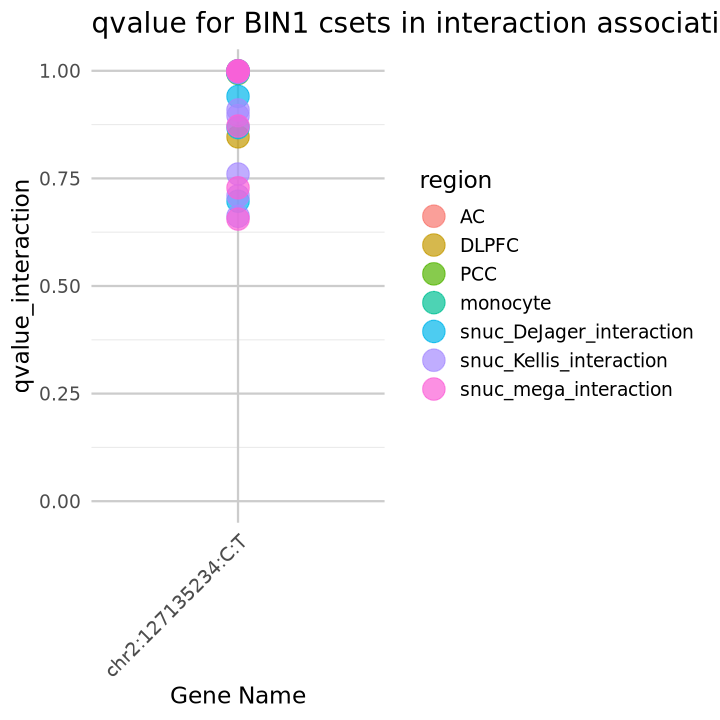

In [13]:
int_apoe_p

In [14]:
# Get a summary table of variants that have statistically significant APOE interaction
BIN1_int_res |> filter(qvalue_interaction < 0.05) |> select(variant_id, molecular_trait_object_id, region, qvalue_interaction)

variant_id,molecular_trait_object_id,region,qvalue_interaction
<chr>,<chr>,<chr>,<dbl>


### Interaction with sex

### Interaction with cell proportion (when available)

This is only available for ROSMAP cohorts where we hae cell proportion estimates

## Quantile QTL analysis

Anjing will soon provide the vignette to assess that.

In [15]:
quant <- readRDS(paste0('/data/analysis_result/quantile_qtl/genome/quantile_qtl_twas_weight/ROSMAP_quantile_eQTL.',chrom, "_", gene_id,'.univariate_qr_twas_weights.rds'))
# Apply imap to access both the element and its name
quant_df <- imap(quant[[gene_id]], function(x, name) {
    x[['qr_screen_pvalue_df']] %>%
        mutate(context = name)  # 'name' holds the name of the current element in the list
}) %>% bind_rows

In [16]:
head(quant_df)

,chr,pos,ref,alt,phenotype_id,variant_id,p_qr,p_qr_0.05,p_qr_0.1,p_qr_0.15,⋯,zscore_qr_0.55,zscore_qr_0.6,zscore_qr_0.65,zscore_qr_0.7,zscore_qr_0.75,zscore_qr_0.8,zscore_qr_0.85,zscore_qr_0.9,zscore_qr_0.95,context
,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
chr2:123880110:T:C...1,2,123880110,T,C,ENSG00000136717,chr2:123880110:T:C,0.4704485,0.7197638,0.9707302,0.84992632,⋯,-2.0482838,-1.4809960,-1.234939163,-0.27595006,-0.26044093,0.14430734,0.932384897,1.4347342,0.7331007,ROSMAP_AC_DeJager_quantile_eQTL_ENSG00000136717
chr2:123880113:TCTACATAATTGCTTCAATTGTGTTTTGTTTGGG:T...2,2,123880113,TCTACATAATTGCTTCAATTGTGTTTTGTTTGGG,T,ENSG00000136717,chr2:123880113:TCTACATAATTGCTTCAATTGTGTTTTGTTTGGG:T,0.4516056,0.7157581,0.9643665,0.85789227,⋯,-2.0210768,-1.4511562,-1.201916553,-0.23942912,-0.21909732,0.19185425,0.983708063,1.4563609,0.7273012,ROSMAP_AC_DeJager_quantile_eQTL_ENSG00000136717
chr2:123880230:G:T...3,2,123880230,G,T,ENSG00000136717,chr2:123880230:G:T,0.7527285,0.1755460,0.2585584,0.36208968,⋯,1.0617451,0.8837454,1.152766068,0.96266065,1.37148287,1.19922512,-0.008580434,0.1874719,-0.5584613,ROSMAP_AC_DeJager_quantile_eQTL_ENSG00000136717
chr2:123881273:G:T...4,2,123881273,G,T,ENSG00000136717,chr2:123881273:G:T,0.9124512,0.1394231,0.3565560,0.07589189,⋯,0.6237366,0.7567487,-0.003892303,0.09067628,-0.03144908,0.03742974,0.082738511,-0.3984493,1.2381879,ROSMAP_AC_DeJager_quantile_eQTL_ENSG00000136717
chr2:123881799:T:C...5,2,123881799,T,C,ENSG00000136717,chr2:123881799:T:C,0.7989276,0.7418350,0.8392487,0.71383644,⋯,-1.9794598,-1.3969239,-1.083232250,-0.20849726,-0.25222265,0.05731796,0.808325793,1.3838059,0.6367950,ROSMAP_AC_DeJager_quantile_eQTL_ENSG00000136717
chr2:123881922:TG:T...6,2,123881922,TG,T,ENSG00000136717,chr2:123881922:TG:T,0.9139877,0.5678646,0.3962810,0.96625675,⋯,0.2585603,0.2203337,0.431309020,0.71075979,0.83920948,0.20288806,-1.077492083,-0.8454761,-0.5750573,ROSMAP_AC_DeJager_quantile_eQTL_ENSG00000136717


In [17]:
# load coef res from quant
quant_coef_df <- imap(quant[[gene_id]], function(x, name) {
    if (!is.null(x[['rq_coef_df']])) {
        x[['rq_coef_df']] %>%
            mutate(context = name)  # 'name' holds the name of the current element in the list
    } else {
        NULL  # 
    }
}) %>% 
    compact() %>%  
    bind_rows()

In [18]:
quant_df_res <- quant_df %>% 
    filter(variant_id %in% coloc_vars, phenotype_id == gene_id) %>% 
    select(variant_id, phenotype_id, qvalue_qr, context) %>% 
    mutate(context = gsub(paste0('_', gene_id), '' , context)) %>% 
    arrange(qvalue_qr)
quant_df_res$variant_id <- factor(quant_df_res$variant_id, levels = unique(quant_df_res$variant_id))
quant_df_res$context <- factor(quant_df_res$context, levels = unique(quant_df_res$context))

### quantile qvalue

In [19]:
quant_df_res |> filter(qvalue_qr < 0.05)

,variant_id,phenotype_id,qvalue_qr,context
,<fct>,<chr>,<dbl>,<fct>
chr2:127135234:C:T...1,chr2:127135234:C:T,ENSG00000136717,1.831713e-19,ROSMAP_Mic_mega_quantile_eQTL
chr2:127135234:C:T...2,chr2:127135234:C:T,ENSG00000136717,1.400909e-04,ROSMAP_AC_DeJager_quantile_eQTL


In [20]:
options(repr.plot.width = 1.1 * length(levels(quant_df_res$context)), repr.plot.height = 6)

if (nrow(quant_df_res) > 0) {
    # Create a bar plot with -log10 transformation for qvalue_qr
    quant_p <- ggplot(quant_df_res %>% filter(qvalue_qr < 0.05), aes(x = context, y = -log10(qvalue_qr), fill = context)) +
        facet_wrap(~variant_id, ncol = 1) +  # Facet by variant_id, placing each variant on a separate row
        geom_bar(stat = "identity") +  # Bar plot, with identity for direct mapping of y-values
        labs(title = "qvalue for BIN1 csets in quantile analysis\n(-log10 transformed)",  # Plot title
             x = "Gene Name",  # X-axis label
             y = "-log10(Quantile qvalue)",  # Y-axis label with -log10 transformation
             fill = "Context") +  # Legend title for the fill color
        theme_minimal(base_size = 14) +  # Minimal theme with adjusted base size
        theme(panel.background = element_blank(),  # Remove panel background
              panel.grid.major = element_line(color = "grey80"),  # Set grid color
              legend.position = NULL,  # Remove legend
              axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) +  # Rotate x-axis labels
        scale_x_discrete(expand = expansion(mult = c(1, 0.1)))  # Expand x-axis for better spacing

    # Save the plot if needed, here is the commented out code for saving
    ggsave('plots/BIN1/sec9.quantile_qvalue.pdf', height = 5, width = 8)
} else {
    # If no data available, display message
    quant_p <- paste0('There are no detectable quantile signals for ', gene_name)
}

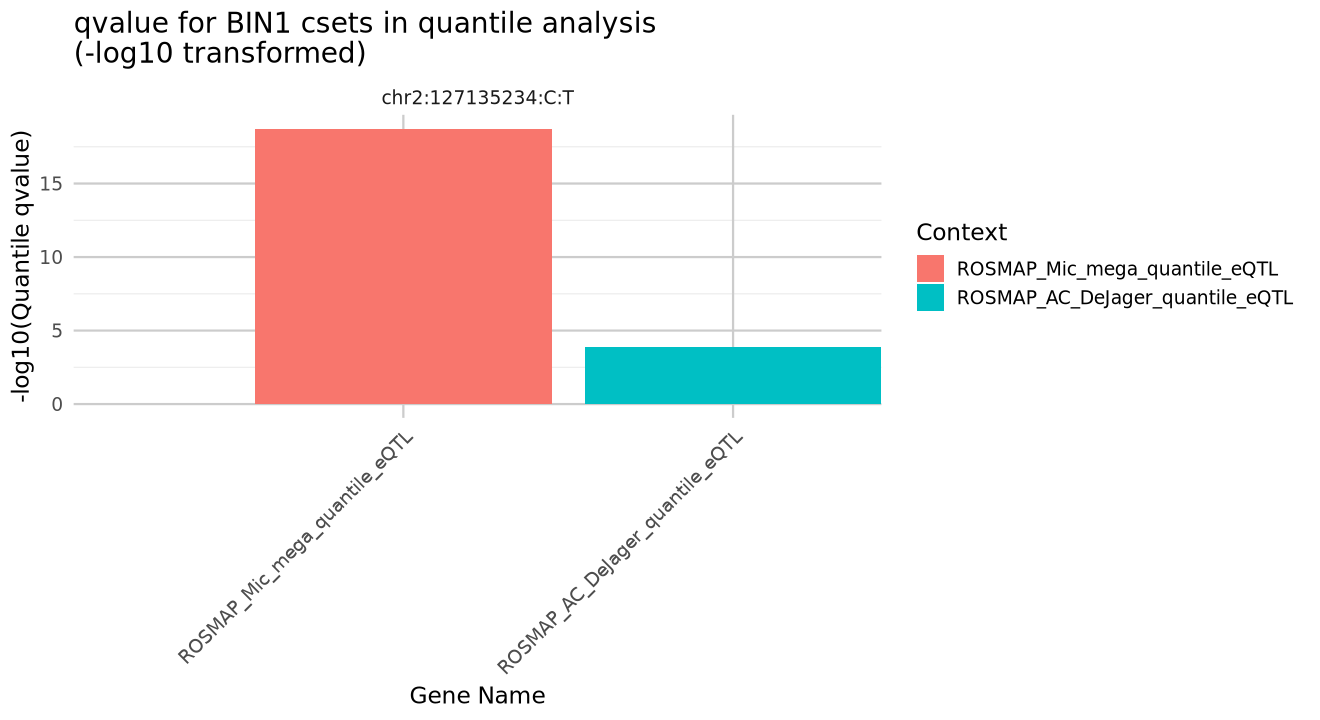

In [21]:
# Display the plot
quant_p

### heterogenity 

In [22]:
#' Calculate Heterogeneity of Beta Coefficients Across Quantiles
#' 
#' This function calculates the heterogeneity of beta coefficients across multiple quantiles for each variant_id.
#' Heterogeneity is computed as log(sd(beta) / abs(mean(beta))).
#' 
#' @param rq_coef_result Data frame containing variant_id and QR coefficient columns
#' @return A data frame with variant_id and heterogeneity values
#' @noRd
calculate_coef_heterogeneity <- function(rq_coef_result) {
  # Identify all the columns starting with "coef_qr_" (quantile regression coefficient columns)
  coef_cols <- grep("^coef_qr_", colnames(rq_coef_result), value = TRUE)
  
  # Create a new data frame with variant_id and heterogeneity
  heterogeneity_result <- data.frame(
    variant_id = rq_coef_result$variant_id,
    phenotype_id = rq_coef_result$phenotype_id,
    context = rq_coef_result$context,
    coef_heter = apply(rq_coef_result[, coef_cols], 1, function(beta) {
      # Compute the mean and standard deviation, ignoring NAs
      beta_mean <- mean(beta, na.rm = TRUE)
      beta_sd <- sd(beta, na.rm = TRUE)
      
      # Handle the case where mean(beta) is 0 to avoid division by zero
      if (abs(beta_mean) == 0) {
        return(NA)  # Return NA if mean is zero
      }
      
      # Compute the heterogeneity: log(sd(beta) / abs(mean(beta)))
      heterogeneity <- log(beta_sd / abs(beta_mean))
      return(heterogeneity)
    }),
    stringsAsFactors = FALSE
  )
  
  # Return only variant_id and heterogeneity
  return(heterogeneity_result)
}

In [23]:
quant_coef_df_int <- quant_coef_df %>% filter(variant_id %in% coloc_vars)
quant_coef_df_int

chr,pos,ref,alt,phenotype_id,variant_id,coef_qr_0.05,coef_qr_0.1,coef_qr_0.15,coef_qr_0.2,⋯,coef_qr_0.55,coef_qr_0.6,coef_qr_0.65,coef_qr_0.7,coef_qr_0.75,coef_qr_0.8,coef_qr_0.85,coef_qr_0.9,coef_qr_0.95,context
<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2,127135234,C,T,ENSG00000136717,chr2:127135234:C:T,0.1309348,0.1540111,0.1143230,0.1364798,⋯,0.1843761,0.1677862,0.1778851,0.1793376,0.1659227,0.1661673,0.1426629,0.1134647,0.1339803,ROSMAP_AC_DeJager_quantile_eQTL_ENSG00000136717
2,127135234,C,T,ENSG00000136717,chr2:127135234:C:T,0.3938607,0.3527098,0.3530068,0.3426469,⋯,0.3113367,0.3196071,0.3098550,0.2960354,0.3142387,0.3103331,0.3272032,0.3153125,0.3420191,ROSMAP_Mic_mega_quantile_eQTL_ENSG00000136717


In [24]:
ylim_min <- quant_coef_df %>% select(starts_with('coef')) %>% min
ylim_max <- quant_coef_df %>% select(starts_with('coef')) %>% max

In [25]:
if(nrow(quant_coef_df_int) > 0){
    df_long <- quant_coef_df_int %>%
      pivot_longer(cols = starts_with("coef_qr"), 
                   names_to = "quantile", 
                   values_to = "coef") %>%
      mutate(quantile = as.numeric(sub("coef_qr_", "", quantile)))
    
    quant_coef_colocvar <- ggplot(df_long, aes(x = quantile, y = coef, group = variant_id)) +
      geom_point(color = 'coral') +
      geom_line(color = 'coral') +
      facet_wrap(~ context + variant_id, scales = "free_y", ncol = 1) +
      labs(title = "Quantile Regression Coefficients for variant Colocalized with AD",
           x = "Quantile",
           y = "Coefficient") +
      ylim(ylim_min, ylim_max)+
      theme_minimal() 
    ggsave('plots/BIN1/sec9.quantitle_coloc_vars.pdf',quant_coef_colocvar,  width = 7, height = 3 * nrow(quant_coef_df_int))
} else quant_coef_colocvar <- c('No variants can be detected in quantile results') 


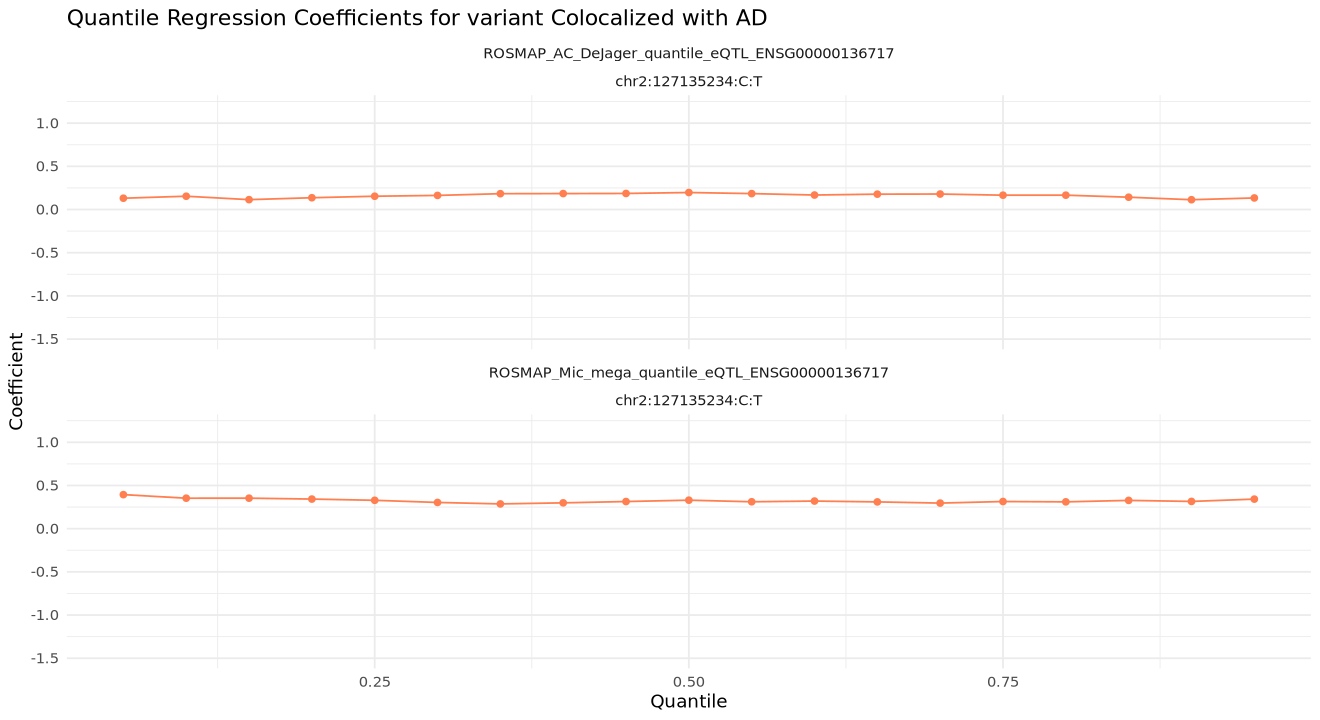

In [26]:
quant_coef_colocvar

In [27]:
# Get a summary table of significant variants for AD with high heterogeneity across quantiles
quant_coef_df_int_het =  calculate_coef_heterogeneity(quant_coef_df_int)
# threshold to be determined

In [28]:
quant_coef_df_int_het

variant_id,phenotype_id,context,coef_heter
<chr>,<chr>,<chr>,<dbl>
chr2:127135234:C:T,ENSG00000136717,ROSMAP_AC_DeJager_quantile_eQTL_ENSG00000136717,-1.851492
chr2:127135234:C:T,ENSG00000136717,ROSMAP_Mic_mega_quantile_eQTL_ENSG00000136717,-2.556099


In [29]:
### Optional: example for variants with high heterogenity

#### 1. heterogeneity coefficient(original/practical)

In [30]:
quant_coef_df_het <- calculate_coef_heterogeneity(quant_coef_df)
notint <- quant_coef_df_het %>% arrange(desc(abs(coef_heter))) %>% tail(n=1) %>% pull(variant_id)

In [31]:
quant_coef_df_notint <- quant_coef_df %>% filter(variant_id %in% notint)

In [32]:
quant_coef_df_notint

chr,pos,ref,alt,phenotype_id,variant_id,coef_qr_0.05,coef_qr_0.1,coef_qr_0.15,coef_qr_0.2,⋯,coef_qr_0.55,coef_qr_0.6,coef_qr_0.65,coef_qr_0.7,coef_qr_0.75,coef_qr_0.8,coef_qr_0.85,coef_qr_0.9,coef_qr_0.95,context
<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2,125748111,G,A,ENSG00000136717,chr2:125748111:G:A,-0.352856,-0.3659031,-0.3684931,-0.4686729,⋯,-0.03134612,-0.0844752,-0.06843777,-0.0435531,-0.1328703,-0.07785475,0.1744672,0.1020176,0.03408206,ROSMAP_AC_DeJager_quantile_eQTL_ENSG00000136717


In [33]:
# Assuming quant_coef_df_notint is already loaded and prepared
# Transforming the data
df_long_notint <- quant_coef_df_notint %>%
  pivot_longer(cols = starts_with("coef_qr"), 
               names_to = "quantile", 
               values_to = "coef") %>%
  mutate(quantile = as.numeric(sub("coef_qr_", "", quantile)))

# Create the plot
quant_coef_highhet <- ggplot(df_long_notint, aes(x = quantile, y = coef, group = variant_id)) +
  geom_point(color = 'darkgreen') +
  geom_line(color = 'darkgreen') +
  facet_wrap(~ context + variant_id, scales = "free_y", ncol = 1) +
  labs(title = paste("Quantile Regression Coefficients for variant with highest heterogeneity"),
       x = "Quantile",
       y = "Coefficient") +
      ylim(ylim_min, ylim_max)+
  theme_minimal() 

# Determine the number of unique contexts to set dynamic height
num_contexts <- length(unique(df_long_notint$context))
# Save the plot
ggsave('plots/BIN1/sec9.quantitle_notcolocvar_coef_highhet.pdf', 
       quant_coef_highhet,  
       width = 7, height = 3 * num_contexts)

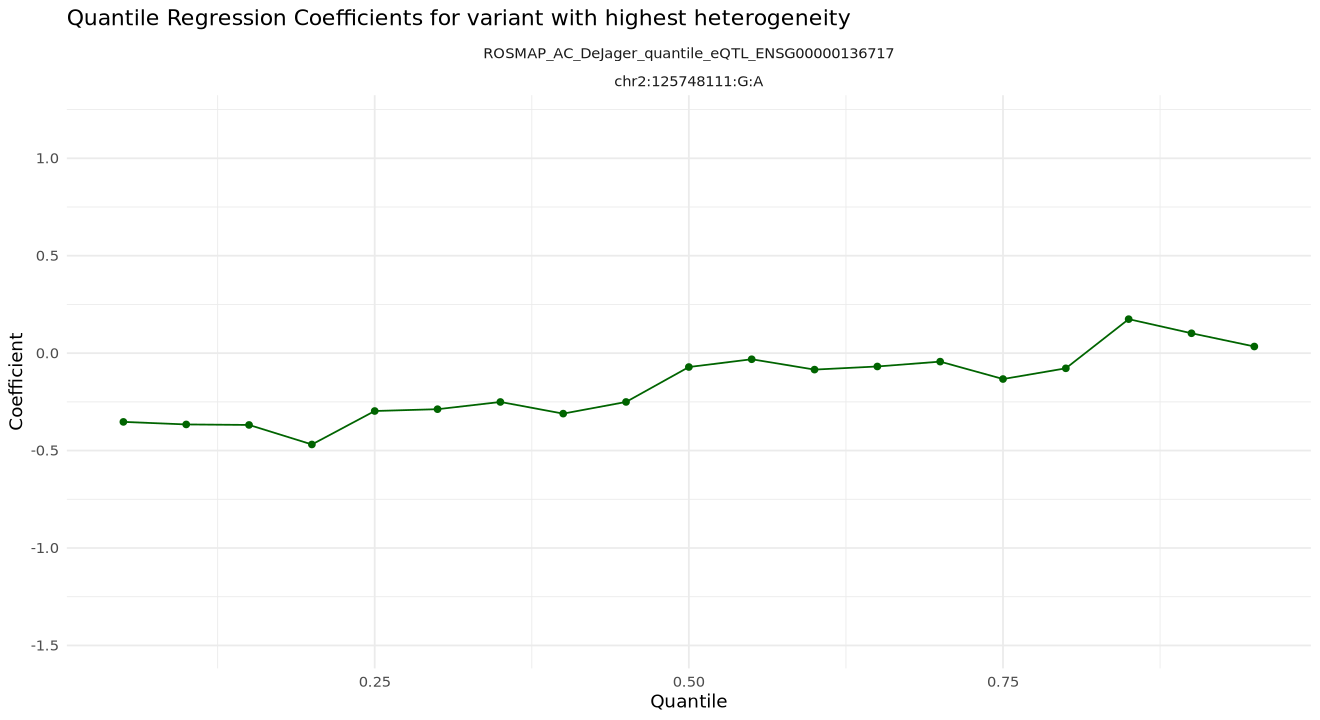

In [34]:
quant_coef_highhet

#### 2. heterogeneity coefficient(theoretical)
heterogeneity_coeficient = log(sd(beta) / abs(mean(beta))), if heterogeneity properly captures the variation and makes the variations comparable across variants. Larger heterogeneity coefficient indicates larger variation in beta coefficient avross quantile. We can see a steeper line during visualizing.

In [35]:
notint <- quant_coef_df_het |> arrange(desc(coef_heter)) %>% head(n=1) %>% pull(variant_id)

In [36]:
quant_coef_df_notint <- quant_coef_df %>% filter(variant_id %in% notint)

In [37]:
# Assuming quant_coef_df_notint is already loaded and prepared
# Transforming the data
df_long_notint <- quant_coef_df_notint %>%
  pivot_longer(cols = starts_with("coef_qr"), 
               names_to = "quantile", 
               values_to = "coef") %>%
  mutate(quantile = as.numeric(sub("coef_qr_", "", quantile)))

# Create the plot
quant_coef_highhet <- ggplot(df_long_notint, aes(x = quantile, y = coef, group = variant_id)) +
  geom_point(color = 'darkgreen') +
  geom_line(color = 'darkgreen') +
  facet_wrap(~ context + variant_id, scales = "free_y", ncol = 1) +
  labs(title = paste("Quantile Regression Coefficients for variant with highest heterogeneity"),
       x = "Quantile",
       y = "Coefficient") +
      ylim(ylim_min, ylim_max)+
  theme_minimal() 

# Determine the number of unique contexts to set dynamic height
num_contexts <- length(unique(df_long_notint$context))
# Save the plot
ggsave('plots/BIN1/sec9.quantitle_notcolocvar_coef_highhet.pdf', 
       quant_coef_highhet,  
       width = 7, height = 3 * num_contexts)

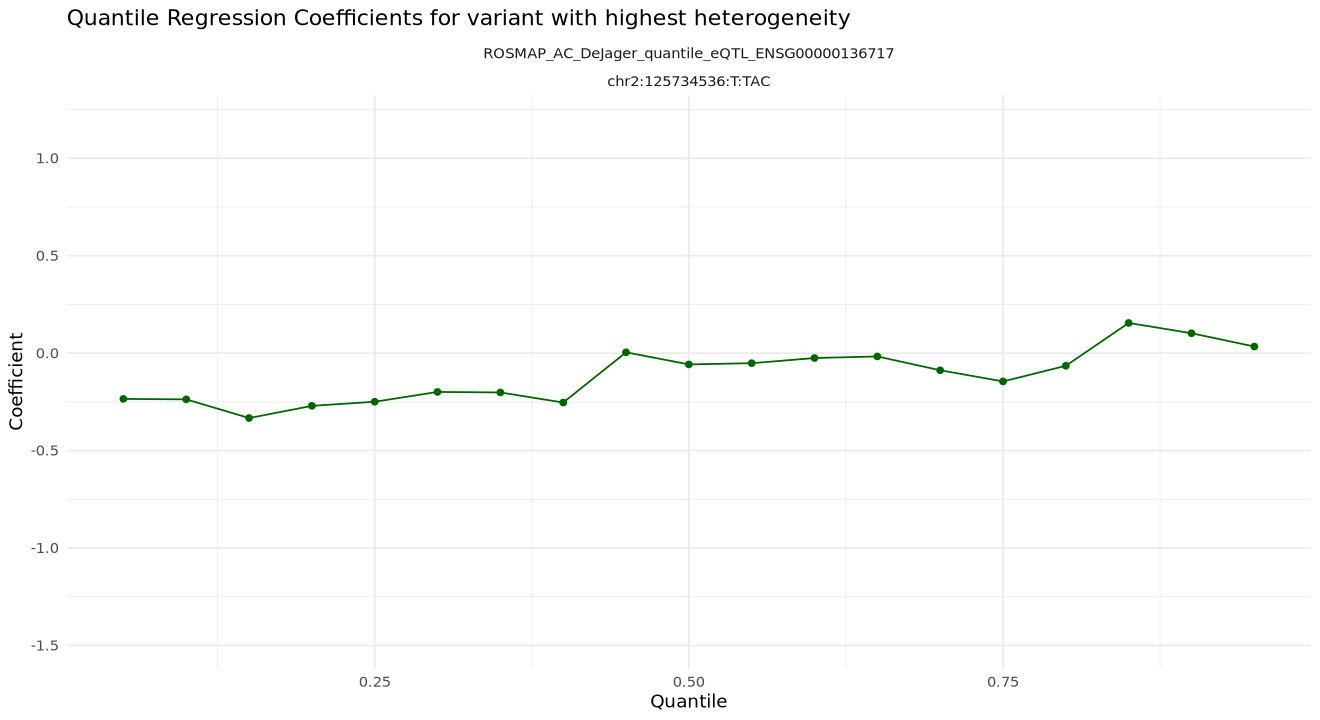

In [38]:
quant_coef_highhet

**The coefficient has limitations in capturing the pattern of variation:**

* It doesn't capture the order/sequence of betas:

Consider two cases with same mean and SD:
Case 1: β(0.1) = 1, β(0.5) = 2, β(0.9) = 3  (monotonic, steep line)
Case 2: β(0.1) = 2, β(0.5) = 1, β(0.9) = 3  (non-monotonic, zigzag)
Both cases could have same heterogeneity coefficient but very different patterns

* Mean might be close to zero:

If mean(β) is close to 0, the coefficient will be large even with moderate SD
This could happen when betas fluctuate around zero without clear trend


**NB: The issue is this heterogeneity coefficient is designed for comparing the heterogeneity across variants. But for this part in 09 section, I believe it's to decide whether the beta coefficients are statistically significant across quantiles.**

#### 3. Fit a linear regression line
I fitted a linear regression line between beta values and quantiles for each variant to capture the overall monotonic trend in beta changes across quantiles, disregarding any "zigzag" variations. While I considered using cubic restricted splines for a more nuanced fit, this approach would be resource-intensive for our primary goal of quickly assessing heterogeneity.

In [39]:
quantile_levels = seq(0.05, 0.95, by=0.05)
quant_coef_df$slope <- apply(quant_coef_df[7:25], 1, function(row) {
    beta_values <- as.numeric(row)  # convert row to numeric
    coef(lm(beta_values ~ quantile_levels))[2] # extract slope coefficient
})

In [40]:
# Select the top 5 variants with the large absolute value of slope
high_het = quant_coef_df |> arrange(desc(abs(slope))) |> head(n=5) #|> pull(variant_id)

In [41]:
high_het

chr,pos,ref,alt,phenotype_id,variant_id,coef_qr_0.05,coef_qr_0.1,coef_qr_0.15,coef_qr_0.2,⋯,coef_qr_0.6,coef_qr_0.65,coef_qr_0.7,coef_qr_0.75,coef_qr_0.8,coef_qr_0.85,coef_qr_0.9,coef_qr_0.95,context,slope
<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
2,128699078,G,A,ENSG00000136717,chr2:128699078:G:A,-0.5691138,-0.6844554,-0.5935008,-0.6766786,⋯,-0.7495411,-0.76182179,-0.7589479,-0.09238352,-0.1982874,-0.2184317,0.3026597,0.40013840,ROSMAP_Oli_mega_quantile_eQTL_ENSG00000136717,0.8640511
2,127864696,C,T,ENSG00000136717,chr2:127864696:C:T,-0.4296459,-0.8746597,-0.9605123,-0.8712569,⋯,-0.6926820,-0.01813026,-0.1339079,-0.13676554,-0.1820118,-0.1919232,-0.3383087,-0.46630012,ROSMAP_Mic_mega_quantile_eQTL_ENSG00000136717,0.8340265
2,124558642,A,G,ENSG00000136717,chr2:124558642:A:G,-0.1192854,-0.2441165,0.3152603,0.2540565,⋯,0.6905718,0.66716386,0.7097159,0.59214269,0.4973504,0.4578163,0.8239383,0.76777390,ROSMAP_Mic_mega_quantile_eQTL_ENSG00000136717,0.7741188
2,130452399,C,A,ENSG00000136717,chr2:130452399:C:A,-1.4842883,-0.6707466,-0.5862145,-0.7520034,⋯,-0.1621506,-0.21725982,-0.2946883,-0.28532354,-0.3134164,-0.3516315,-0.4797480,-0.05206628,ROSMAP_AC_DeJager_quantile_eQTL_ENSG00000136717,0.7259502
2,130580524,C,T,ENSG00000136717,chr2:130580524:C:T,-1.4842883,-0.7488682,-0.5892134,-0.7591401,⋯,-0.1932392,-0.25708228,-0.2859248,-0.34326055,-0.3313030,-0.4562050,-0.5110362,-0.04866361,ROSMAP_AC_DeJager_quantile_eQTL_ENSG00000136717,0.7106386


In [42]:
quant_coef_df_high_het = quant_coef_df  %>% filter(variant_id %in% high_het) |> arrange(desc(abs(slope)))

In [43]:
df_long_high_het <-high_het %>%
  pivot_longer(cols = starts_with("coef_qr"), 
               names_to = "quantile", 
               values_to = "coef") %>%
  mutate(quantile = as.numeric(sub("coef_qr_", "", quantile)))

# Create the plot
quant_coef_highhet <- ggplot(df_long_high_het, aes(x = quantile, y = coef, group = variant_id)) +
  geom_point(color = 'darkgreen') +
  geom_line(color = 'darkgreen') +
  facet_wrap(~ context + variant_id, scales = "free_y", ncol = 1) +
  labs(title = paste("Quantile Regression Coefficients for variant with highest heterogeneity"),
       x = "Quantile",
       y = "Coefficient") +
      ylim(ylim_min, ylim_max)+
  theme_minimal() 

# Determine the number of unique contexts to set dynamic height
num_contexts <- length(unique(df_long_high_het$context))
# Save the plot
ggsave('plots/BIN1/sec9.quantitle_notcolocvar_coef_highhet.pdf', 
       quant_coef_highhet,  
       width = 7, height = 3 * num_contexts)

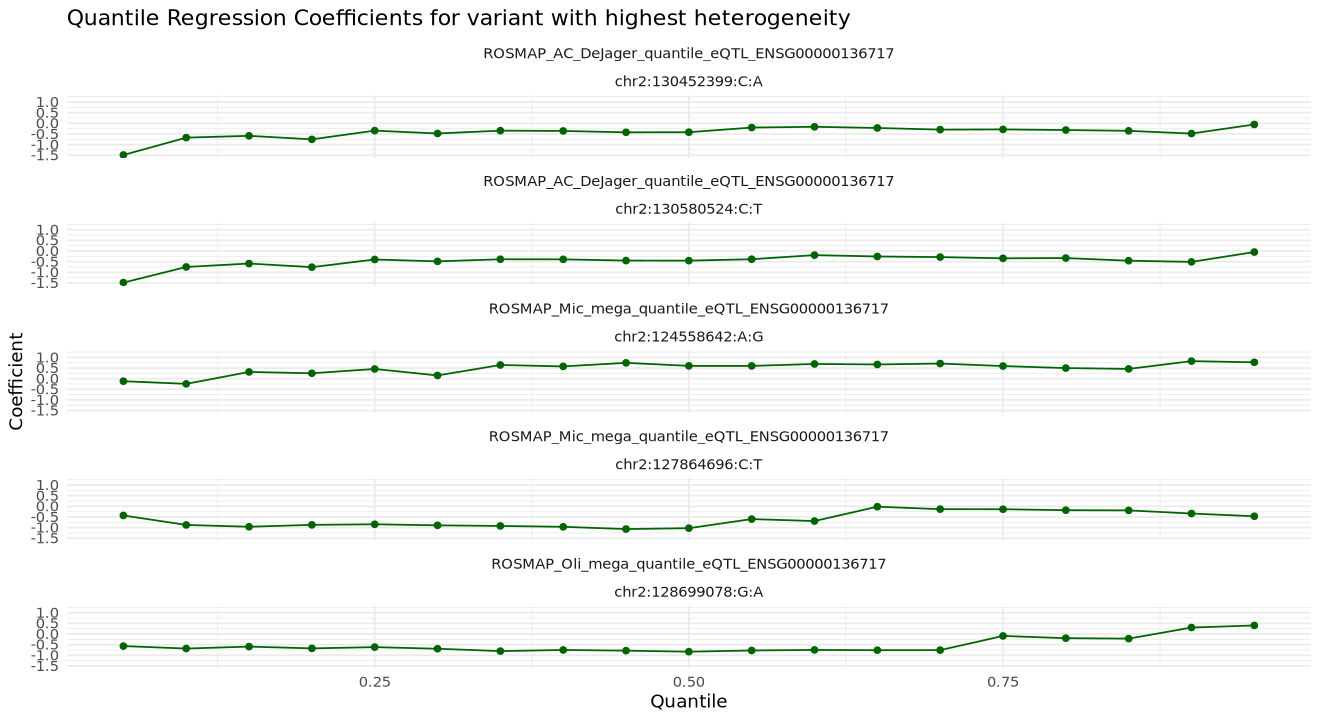

In [44]:
quant_coef_highhet

**Results: This linear regression approach effectively captures variants with high heterogeneity, exemplified by the variant chr2:130047952:A, as demonstrated in the original notebook. Additionally, a statistical test for the null hypothesis, 
𝐻0:𝛽=0, can assess whether the observed beta coefficients exhibit significant heterogeneity.**

In [45]:
# Add statistical test results
quant_coef_df <- quant_coef_df %>% 
    as.data.frame() %>%
    rowwise() %>%
    mutate(
        t_value = summary(lm(as.numeric(c_across(7:25)) ~ quantile_levels))$coefficients[2,3],
        p_value = summary(lm(as.numeric(c_across(7:25)) ~ quantile_levels))$coefficients[2,4]
    )

In [46]:
quant_coef_df |> filter(p_value <0.05)
num_sig_variants <- nrow(quant_coef_df |> filter(p_value <0.05))
cat(sprintf("**Results:** %d variants are significantly heterogeneous in beta coefficients across quantiles.", num_sig_variants))

chr,pos,ref,alt,phenotype_id,variant_id,coef_qr_0.05,coef_qr_0.1,coef_qr_0.15,coef_qr_0.2,⋯,coef_qr_0.7,coef_qr_0.75,coef_qr_0.8,coef_qr_0.85,coef_qr_0.9,coef_qr_0.95,context,slope,t_value,p_value
<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
2,125151923,C,T,ENSG00000136717,chr2:125151923:C:T,-0.3857698,-0.5061867,-0.4411981,-0.5005613,⋯,-0.35401787,-0.40231476,-0.40099173,0.005349841,0.10697615,0.02878511,ROSMAP_AC_DeJager_quantile_eQTL_ENSG00000136717,0.48398011,4.203366,5.972692e-04
2,125748111,G,A,ENSG00000136717,chr2:125748111:G:A,-0.3528560,-0.3659031,-0.3684931,-0.4686729,⋯,-0.04355310,-0.13287032,-0.07785475,0.174467184,0.10201759,0.03408206,ROSMAP_AC_DeJager_quantile_eQTL_ENSG00000136717,0.57494270,9.018044,6.887380e-08
2,127068683,A,G,ENSG00000136717,chr2:127068683:A:G,-0.1690143,-0.1888159,-0.2119991,-0.2168085,⋯,-0.22501515,-0.23893848,-0.28765748,-0.303688652,-0.25189655,-0.20319163,ROSMAP_AC_DeJager_quantile_eQTL_ENSG00000136717,-0.07596353,-3.296887,4.258620e-03
2,127107524,G,A,ENSG00000136717,chr2:127107524:G:A,-0.1359134,-0.1690559,-0.1749194,-0.1652076,⋯,-0.13298339,-0.11216632,-0.11904450,-0.127271562,-0.10386608,-0.12646736,ROSMAP_AC_DeJager_quantile_eQTL_ENSG00000136717,0.06393598,4.264240,5.237986e-04
2,127108971,G,A,ENSG00000136717,chr2:127108971:G:A,-0.2339220,-0.3206972,-0.2998868,-0.3611433,⋯,-0.35440515,-0.38704122,-0.36758779,-0.380695258,-0.38440136,-0.35439072,ROSMAP_AC_DeJager_quantile_eQTL_ENSG00000136717,-0.08758260,-3.361477,3.703940e-03
2,127137911,G,A,ENSG00000136717,chr2:127137911:G:A,0.1871179,0.1717096,0.1707743,0.1954429,⋯,0.07971033,0.06227206,0.04542879,0.037935726,0.02517259,0.04687870,ROSMAP_AC_DeJager_quantile_eQTL_ENSG00000136717,-0.20394204,-12.927715,3.194560e-10
2,127204500,G,A,ENSG00000136717,chr2:127204500:G:A,-0.1620262,-0.1836277,-0.2195266,-0.2225899,⋯,-0.50450401,-0.50924221,-0.50047814,-0.536461299,-0.60332576,-0.47197443,ROSMAP_AC_DeJager_quantile_eQTL_ENSG00000136717,-0.47338190,-13.688523,1.310105e-10
2,127320734,C,T,ENSG00000136717,chr2:127320734:C:T,-0.1665697,-0.4253284,-0.5173377,-0.4520239,⋯,-0.79802851,-0.75589636,-0.88895006,-0.481352342,-0.57305728,-0.74672519,ROSMAP_AC_DeJager_quantile_eQTL_ENSG00000136717,-0.41696601,-4.152645,6.663976e-04
2,127823057,A,G,ENSG00000136717,chr2:127823057:A:G,-0.1813787,-0.3827407,-0.3642971,-0.5096512,⋯,-0.85780719,-0.80309893,-0.89696254,-0.934769055,-0.58350662,-0.75764375,ROSMAP_AC_DeJager_quantile_eQTL_ENSG00000136717,-0.59954976,-6.636908,4.200744e-06


**Results:** 72 variants are significantly heterogeneous in beta coefficients across quantiles.